<div style="border:solid Chocolaчфte 2px; padding: 40px">

<b>Иван, привет!👋</b>

Меня зовут Ольга Бессолицына, мчфентор, я буду проверять твой проект.

Пожалуйста, не удаляй мои комментарии, они будут особенно полезны для нашей работы в случае повторной проверки проекта. 

Ты можешь найти мои комментарии, обозначенные <font color='green'>зеленым</font>, <font color='gold'>желтым</font> и <font color='red'>красным</font> цветами, например:

<br/>

<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> В случае, если решение на отдельном шаге является полностью правильным.
</div>

<br/>

<div class="alert alert-warning">
    <h2> Комментарий ментора <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> В случае, когда решение на отдельном шаге станет еще лучше, если внести небольшие коррективы.
</div>


<br/>
<div class="alert alert-block alert-danger">
<h2> Комментарий ментора <a class="tocSkip"></h2>

    
<b>На доработку🤔:</b>
 В случае, когда решение на отдельном шаге требует существенной переработки и внесения правок. Напоминаю, что проект не может быть принят с первого раза, если ревью содержит комментарии, рекомендующие доработать шаги.
</div>

# Модель предсказания оттока клиентов

## Описание проекта

Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Им нужна модель машинного обучения, чтобы заранее выявлять абонентов, склоняющихся к расторжению договора. 

**Цель проекта:** построить модель машинного обучения, предсказывающую вероятность оттока на основе персональных данных, характеристик тарифов и подключенных услуг. ROC-AUC должен быть выше 0.85. Для финального предсказания нужно изучить значения других метрик и матрицу ошибок. Изучить важность признаков.

Мы будем использовать данные из SQLite базы данных.

## Описание данных

Данные хранятся в Sqlite  — СУБД, в которой база данных представлена одним файлом. Она состоит из нескольких таблиц:

- `contract` — информация о договорах;
- `personal` — персональные данные клиентов;
- `internet` — информация об интернет-услугах;
- `phone` — информация об услугах телефонии.

Таблица `contract`:
- `customerID` — ID абонента;
- `BeginDate` — дата начала действия договора;
- `EndDate` — дата окончания действия договора;
- `Type` — тип оплаты: раз в год-два или ежемесячно;
- `PaperlessBilling` — электронный расчётный лист;
- `PaymentMethod` — тип платежа;
- `MonthlyCharges` — расходы за месяц;
- `TotalCharges` — общие расходы абонента.

Таблица `personal`:
- `customerID` — ID пользователя;
- `gender` — пол;
- `SeniorCitizen` — является ли абонент пенсионером;
- `Partner` — есть ли у абонента супруг или супруга;
- `Dependents` — есть ли у абонента дети.

Таблица `internet`:
- `customerID` — ID пользователя;
- `InternetService` — тип подключения;
- `OnlineSecurity` — блокировка опасных сайтов;
- `OnlineBackup` — облачное хранилище файлов для резервного копирования данных;
- `DeviceProtection` — антивирус;
- `TechSupport` — выделенная линия технической поддержки;
- `StreamingTV` — стриминговое телевидение;
- `StreamingMovies` — каталог фильмов.

Таблица `phone`:
- `customerID` — ID пользователя;
- `MultipleLines` — подключение телефона к нескольким линиям одновременно.

Информация о договорах актуальна на 1 февраля 2020.

<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b>
 Молодец, что не забываешь про заголовок и описание, это важно, так и самому удобнее работать, когда они всегда на виду, так и другим будет проще понять, что происходит в твоей тетради :)
</div>

## Подготовка к проекту (импорт библиотек, определение констант)

### Загрузка библиотек.

In [1]:
# !pip install phik

In [2]:
# !pip install catboost

<div class="alert alert-warning">
<h2> Комментарий ментора <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 
    
* Чтобы вся эта информация не выводилась при установке, можно добавить в конце строки `-q`.
    
    
* Чтабы запустить сразу несколько установок в одной ячейке, в начаое строки необходимо поставить восклицательный знак: `!pip install ...`

### Импорт библиотек.

In [3]:
import os
import pandas as pd
from sqlalchemy import create_engine

import matplotlib.pyplot as plt
import seaborn as sns
import phik
import numpy as np

import optuna
from optuna.samplers import TPESampler

import torch
import torch.nn as nn

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, classification_report
from sklearn.model_selection import StratifiedKFold

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from time import time
import warnings
warnings.filterwarnings('ignore')

### Определение значения `RANDOM_STATE` и других констант.

In [4]:
RANDOM_STATE = 11225

Подключение к базе данных.

In [5]:
db_filename = 'ds-plus-final.db'

In [6]:
try:
    engine = create_engine(f'sqlite:///{db_filename}', echo=False)
    print("Подключение к базе данных установлено.")
except:
    print("Файл базы данных не найден.")

Подключение к базе данных установлено.


## Загрузка данных и первичное ознакомление

Напишем функцию для ознакомления с данными

In [7]:
def inspect_table(df):
    print(f"Размер: {df.shape}")
    print('='*150)
    print("\nПервые 5 строк")
    display(df.head(5))
    print('='*150)
    print("\nИнформация о типах и пропусках")
    display(df.info())
    print('='*150)
    print("\nКоличество пропусков по столбцам")
    display(df.isnull().sum())
    print('='*150)
    print("\nКоличество полных дубликатов строк")
    display(df.duplicated().sum())
    print('='*150)

### `contract` — информация о договорах

Таблица `contract`:
- `customerID` — ID абонента;
- `BeginDate` — дата начала действия договора;
- `EndDate` — дата окончания действия договора;
- `Type` — тип оплаты: раз в год-два или ежемесячно;
- `PaperlessBilling` — электронный расчётный лист;
- `PaymentMethod` — тип платежа;
- `MonthlyCharges` — расходы за месяц;
- `TotalCharges` — общие расходы абонента.

In [8]:
contract = pd.read_sql("SELECT * FROM contract", con=engine)
inspect_table(contract)

Размер: (7043, 8)

Первые 5 строк


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5



Информация о типах и пропусках
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   BeginDate         7043 non-null   object
 2   EndDate           7043 non-null   object
 3   Type              7043 non-null   object
 4   PaperlessBilling  7043 non-null   object
 5   PaymentMethod     7043 non-null   object
 6   MonthlyCharges    7043 non-null   object
 7   TotalCharges      7043 non-null   object
dtypes: object(8)
memory usage: 440.3+ KB


None


Количество пропусков по столбцам


customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


Количество полных дубликатов строк


np.int64(0)

### `personal` — персональные данные клиентов|

Таблица `personal`:
- `customerID` — ID пользователя;
- `gender` — пол;
- `SeniorCitizen` — является ли абонент пенсионером;
- `Partner` — есть ли у абонента супруг или супруга;
- `Dependents` — есть ли у абонента дети.

In [9]:
personal = pd.read_sql("SELECT * FROM personal", con=engine)
inspect_table(personal)

Размер: (7043, 5)

Первые 5 строк


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No



Информация о типах и пропусках
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   object
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: object(5)
memory usage: 275.2+ KB


None


Количество пропусков по столбцам


customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64


Количество полных дубликатов строк


np.int64(0)

### `internet` — информация об интернет-услугах

Таблица `internet`:
- `customerID` — ID пользователя;
- `InternetService` — тип подключения;
- `OnlineSecurity` — блокировка опасных сайтов;
- `OnlineBackup` — облачное хранилище файлов для резервного копирования данных;
- `DeviceProtection` — антивирус;
- `TechSupport` — выделенная линия технической поддержки;
- `StreamingTV` — стриминговое телевидение;
- `StreamingMovies` — каталог фильмов.

In [10]:
internet = pd.read_sql("SELECT * FROM internet", con=engine)
inspect_table(internet)

Размер: (5517, 8)

Первые 5 строк


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No



Информация о типах и пропусках
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


None


Количество пропусков по столбцам


customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64


Количество полных дубликатов строк


np.int64(0)

### `phone` — информация об услугах телефонии

Таблица `phone`:
- `customerID` — ID пользователя;
- `MultipleLines` — подключение телефона к нескольким линиям одновременно.

In [11]:
phone = pd.read_sql("SELECT * FROM phone", con=engine)
inspect_table(phone)

Размер: (6361, 2)

Первые 5 строк


,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes



Информация о типах и пропусках
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerId     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


None


Количество пропусков по столбцам


CustomerId       0
MultipleLines    0
dtype: int64


Количество полных дубликатов строк


np.int64(0)

### Вывод

- Данные соответствуют описанию.
- В данных нет пропусков, до объединения.
- В данных нет явных дубликатов.
- Типы данных сразу в нескольких столбцах некорректны.
- Мы уже можем обратить внимание на меньшее количество пользователей интернет-услуг относительная общего числа пользователей.

<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> данные загружены корректно

## Анализ данных

### Предобработка

#### `contract` — информация о договорах

Исправим ошибки в типах данных.

In [12]:
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'])

contract['EndDate'] = pd.to_datetime(contract['EndDate'], errors='coerce')

contract['MonthlyCharges'] = pd.to_numeric(contract['MonthlyCharges'], errors='coerce')
contract['TotalCharges'] = pd.to_numeric(contract['TotalCharges'], errors='coerce')

In [13]:
inspect_table(contract[['BeginDate', 'EndDate', 'MonthlyCharges', 'TotalCharges']])

Размер: (7043, 4)

Первые 5 строк


,BeginDate,EndDate,MonthlyCharges,TotalCharges
0,2020-01-01,NaT,29.85,31.04
1,2017-04-01,NaT,56.95,2071.84
2,2019-10-01,NaT,53.85,226.17
3,2016-05-01,NaT,42.30,1960.60
4,2019-09-01,NaT,70.70,353.50



Информация о типах и пропусках
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   BeginDate       7043 non-null   datetime64[ns]
 1   EndDate         1101 non-null   datetime64[ns]
 2   MonthlyCharges  7043 non-null   float64       
 3   TotalCharges    7032 non-null   float64       
dtypes: datetime64[ns](2), float64(2)
memory usage: 220.2 KB


None


Количество пропусков по столбцам


BeginDate            0
EndDate           5942
MonthlyCharges       0
TotalCharges        11
dtype: int64


Количество полных дубликатов строк


np.int64(174)

Если пропуски в EndDate были задуманы, то вот пропуски в TotalCharges - это неожиданно.

In [14]:
contract[contract['TotalCharges'].isnull()]

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,NaT,Two year,Yes,Bank transfer (automatic),52.55,NaN
753,3115-CZMZD,2020-02-01,NaT,Two year,No,Mailed check,20.25,NaN
936,5709-LVOEQ,2020-02-01,NaT,Two year,No,Mailed check,80.85,NaN
1082,4367-NUYAO,2020-02-01,NaT,Two year,No,Mailed check,25.75,NaN
1340,1371-DWPAZ,2020-02-01,NaT,Two year,No,Credit card (automatic),56.05,NaN
3331,7644-OMVMY,2020-02-01,NaT,Two year,No,Mailed check,19.85,NaN
3826,3213-VVOLG,2020-02-01,NaT,Two year,No,Mailed check,25.35,NaN
4380,2520-SGTTA,2020-02-01,NaT,Two year,No,Mailed check,20.00,NaN
5218,2923-ARZLG,2020-02-01,NaT,One year,Yes,Mailed check,19.70,NaN
6670,4075-WKNIU,2020-02-01,NaT,Two year,No,Mailed check,73.35,NaN


Все они имеют общую начальную дату, которая является последней в наборе данных, это люди еще не внесшие платежи. Обработаем на месте, их `TotalCharges` равны `MonthlyCharges`.

In [15]:
contract.loc[contract['TotalCharges'].isnull(), 'TotalCharges'] = contract.loc[contract['TotalCharges'].isnull(), 'MonthlyCharges']

In [16]:
contract['TotalCharges'].isnull().sum()

np.int64(0)

<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> отлично, согласна

#### `personal` — персональные данные клиентов|

In [17]:
personal['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Столбец булев, мы приведем его к общему виду с другими столбцами и заменим 1 на Yes а 0 на No.

In [18]:
personal['SeniorCitizen'] = personal['SeniorCitizen'].map({'1': 'Yes', '0': 'No'})

In [19]:
personal['SeniorCitizen'].value_counts()

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

#### `internet` — информация об интернет-услугах

В данной таблице преобразования не требуются.

#### `phone` — информация об услугах телефонии

В данной таблице нет ошибок, исправим опечатку в названии колонки `customerID`.

In [20]:
phone.rename(columns={'CustomerId': 'customerID'}, inplace=True)

### Создание признаков

#### Целевая переменная

In [21]:
contract['is_active'] = contract['EndDate'].isna().astype(int)

<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b>таргет выделен верно

#### Длительность контракта в днях

In [22]:
cutoff_date = pd.to_datetime('2020-02-01')

In [23]:
# contract['tenure_days'] = (cutoff_date - contract['BeginDate']).dt.days // 30

In [24]:
effective_end = contract["EndDate"].fillna(cutoff_date)
effective_end = effective_end.apply(lambda d: min(d, cutoff_date))

contract["tenure_days"] = ((effective_end - contract["BeginDate"]).dt.days).clip(lower=0)

<div class="alert alert-block alert-danger">
<h2> Комментарий ментора <a class="tocSkip"></h2>

    
<b>На доработку🤔:</b> почему считаем от среза данных? Для ушедших клиентов это корректно?
    
Если контракт действовал месяц в 2015 году например, а мы записываем вместо 1го месяца - около 5 лет.
    
Возможна утечка из-за этого признака

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента</b></font>
Заменил на признак `tenure_days`.
Исправил расчет `tenure_days`, теперь если дата окончания `EndDate` есть для пользователя, `tenure_days` рассчитывается по разнице между началом и концом, а если `EndDate` нет, то рассчитывается по разнице между датой среза и датой начала.
</div>

<div class="alert alert-success">
<h2> Комментарий ментора 2<a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> доработано

In [25]:
contract['tenure_days'].value_counts().sort_index()

tenure_days
0        11
28        1
30        1
31      236
59        3
       ... 
2163    115
2191    265
2253      1
2283      2
2314      3
Name: count, Length: 251, dtype: int64

Для того, чтобы не было утечки признаков столбцы `BeginDate` и `EndDate` мы удалим, когда будем приступать к обучению.

### Исследование категориальных признаков

Напишем функцию.

In [26]:
def plot_categorical(df, max_categories=10):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(categorical_cols) == 0:
        print("Нет категориальных столбцов.")
        return

    for col in categorical_cols:
        value_counts = df[col].value_counts()
        if len(value_counts) > max_categories:
            top = value_counts[:max_categories - 1]
            other = value_counts[max_categories - 1:].sum()
            value_counts = pd.concat([
                top, 
                pd.Series([other], index=['Other'])
            ])
        
        plt.figure(figsize=(7, 7))
        plt.pie(
            value_counts,
            labels=value_counts.index,
            autopct='%1.1f%%',
            startangle=90
        )
        plt.title(f'Pie chart: {col}')
        plt.axis('equal')
        plt.show()

#### `contract` — информация о договорах

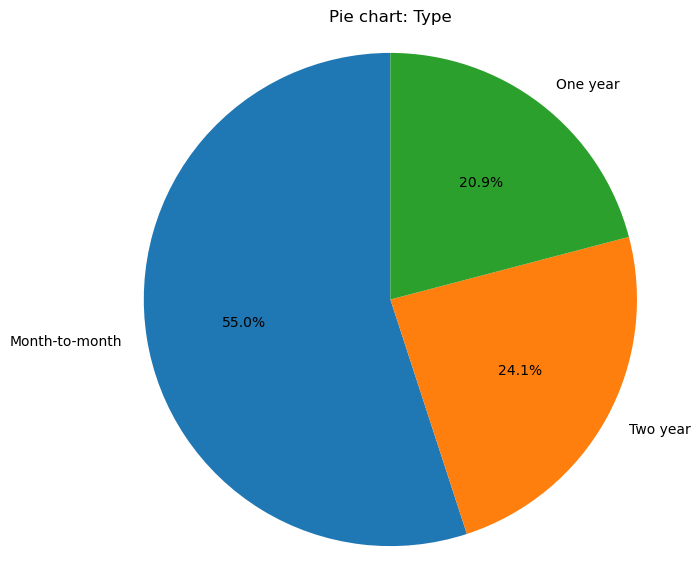

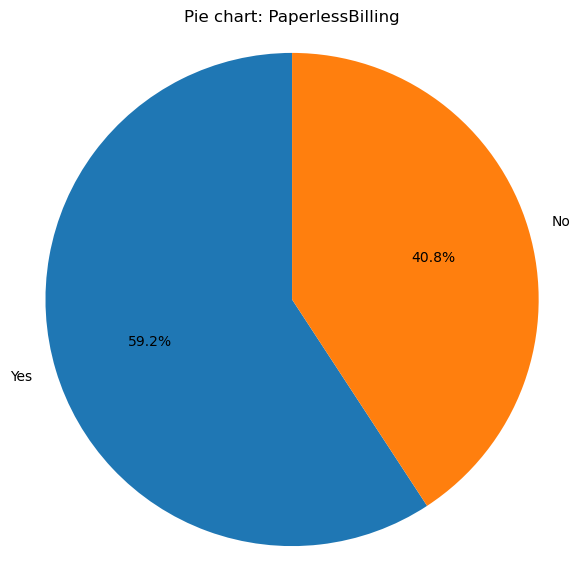

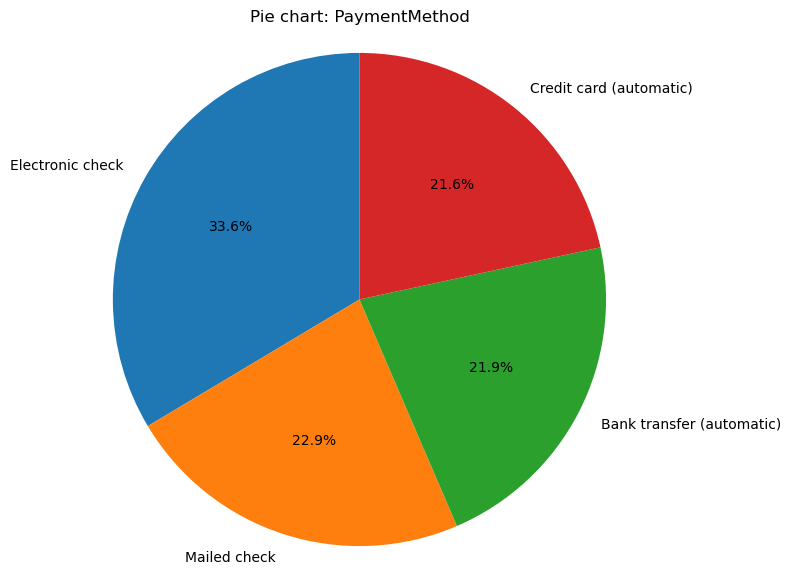

In [27]:
plot_categorical(contract.drop(columns='customerID'))

#### `personal` — персональные данные клиентов|

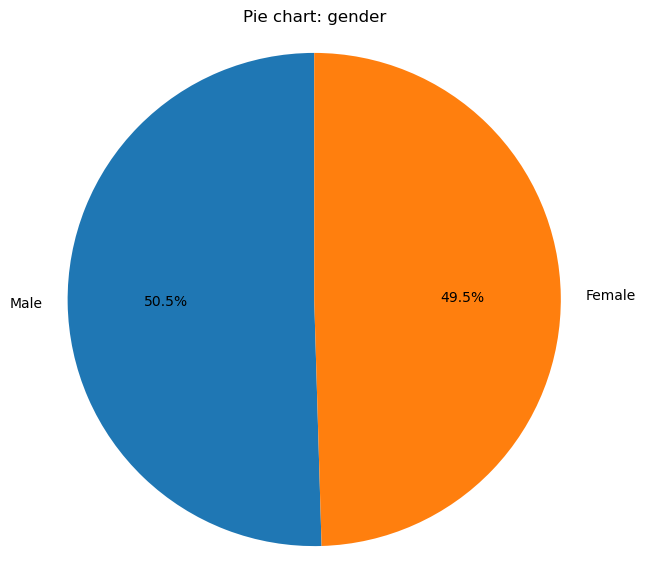

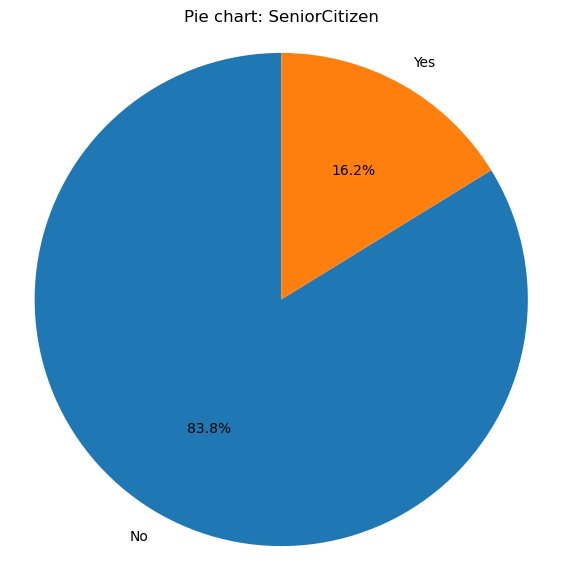

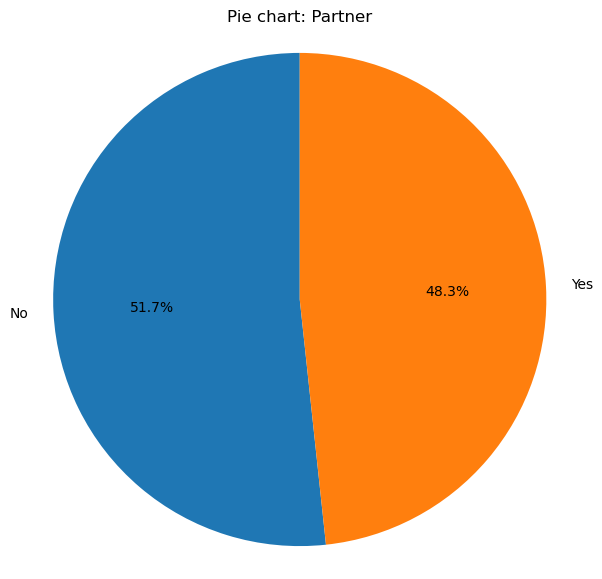

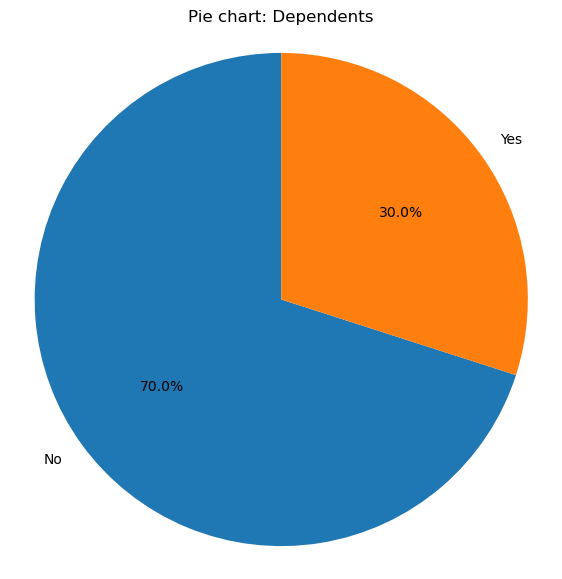

In [28]:
plot_categorical(personal.drop(columns='customerID'))

#### `internet` — информация об интернет-услугах

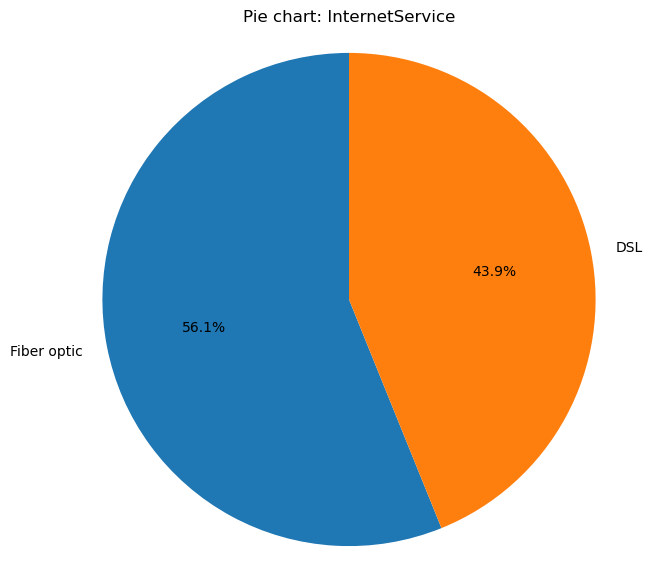

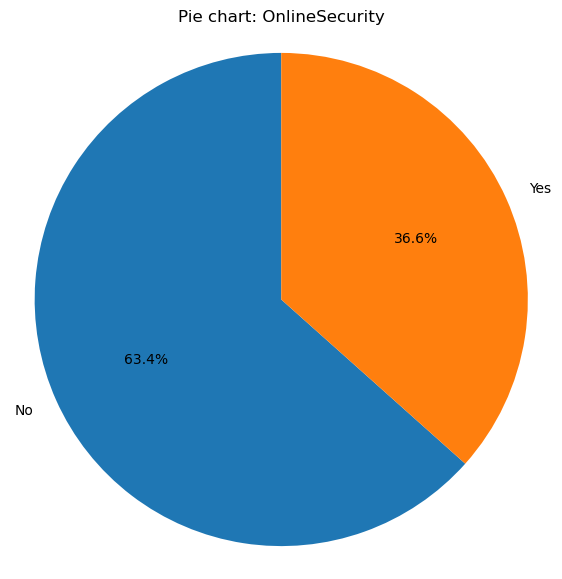

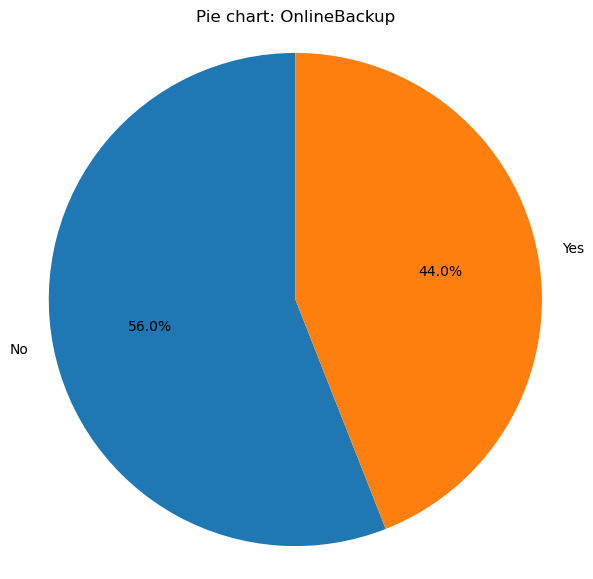

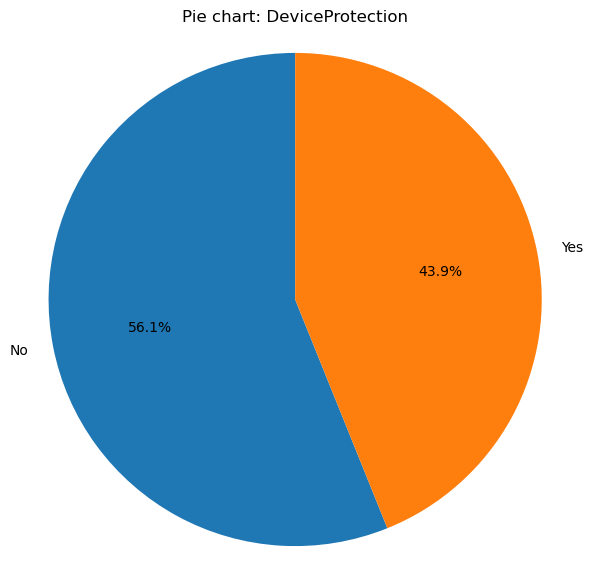

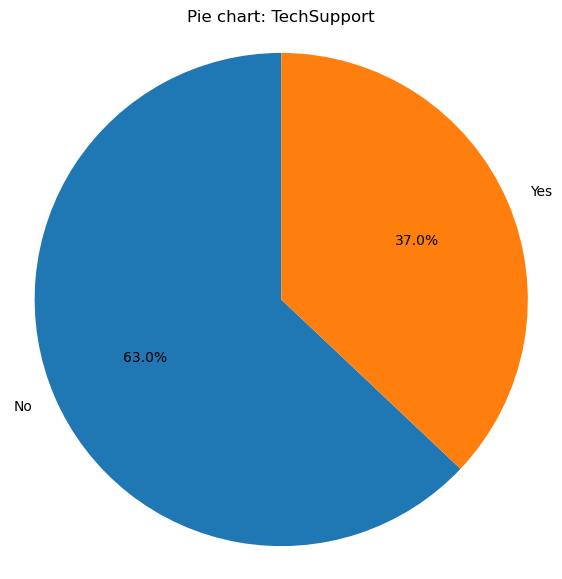

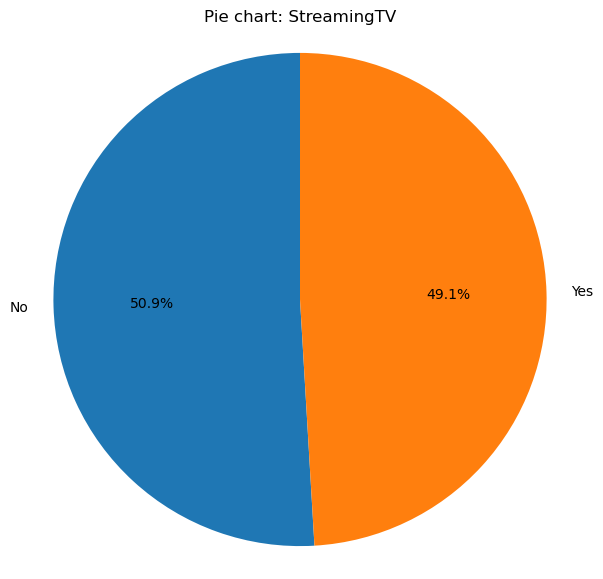

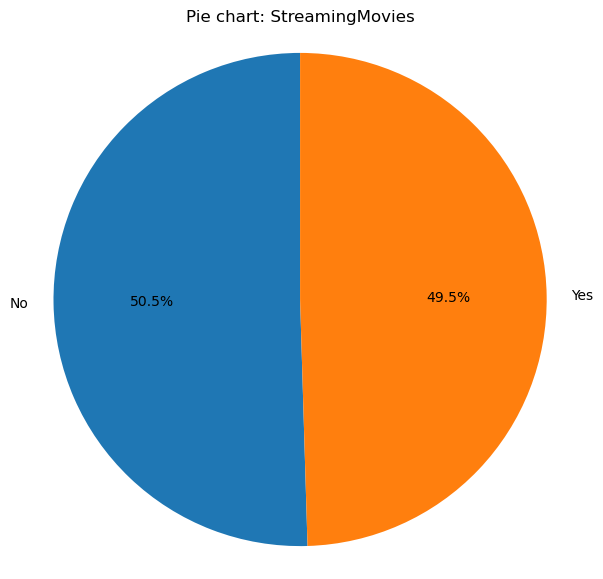

In [29]:
plot_categorical(internet.drop(columns='customerID'))

#### `phone` — информация об услугах телефонии

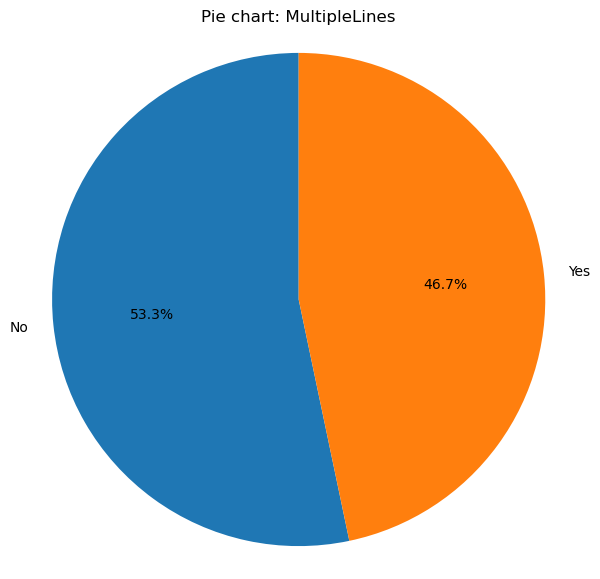

In [30]:
plot_categorical(phone.drop(columns='customerID'))

### Исследование численных признаков

In [31]:
def plot_numeric(df):
    numeric_cols = df.select_dtypes(include=['number']).columns
    if len(numeric_cols) == 0:
        print("Нет числовых столбцов.")
        return

    for col in numeric_cols:
        mean_val = df[col].mean()
        median_val = df[col].median()
        
        fig, axes = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [9, 1]})
        
        sns.histplot(df[col], kde=True, ax=axes[0])
        axes[0].axvline(mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.2f}')
        axes[0].axvline(median_val, color='green', linestyle='-', label=f'Медиана: {median_val:.2f}')
        axes[0].legend()
        axes[0].set_title(f'Гистограмма + KDE: {col}')
        axes[0].set_xlabel(col)
        
        sns.boxplot(x=df[col], ax=axes[1])
        axes[1].set_xlabel(col)
        axes[1].axvline(mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.2f}')
        axes[1].axvline(median_val, color='green', linestyle='-', label=f'Медиана: {median_val:.2f}')
        
        plt.tight_layout()
        plt.show()

#### `contract` — информация о договорах

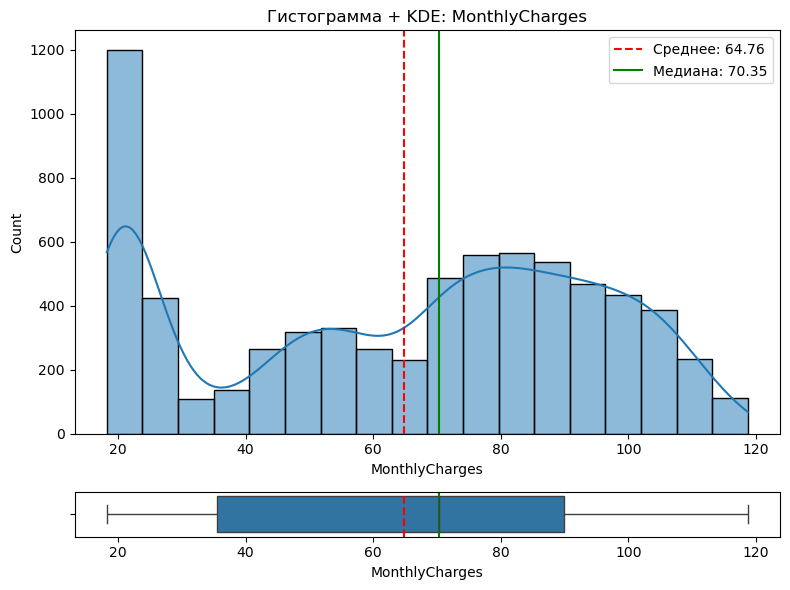

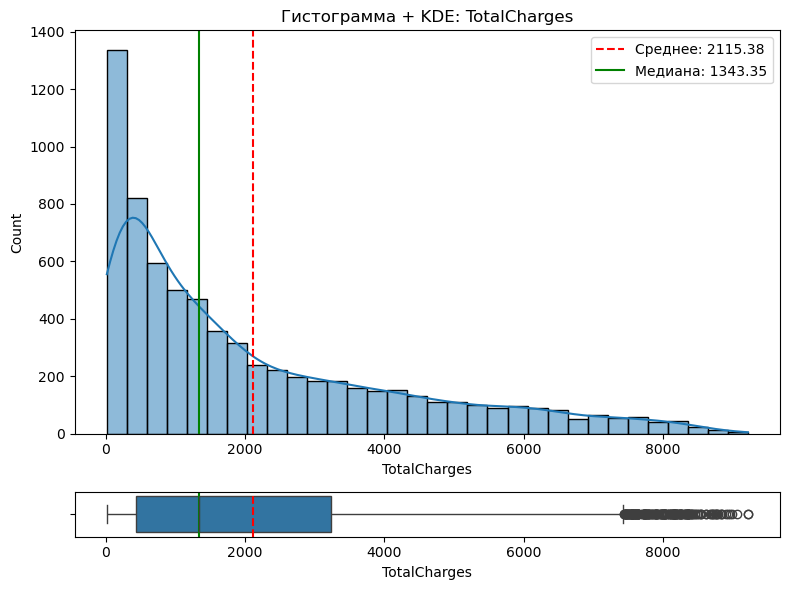

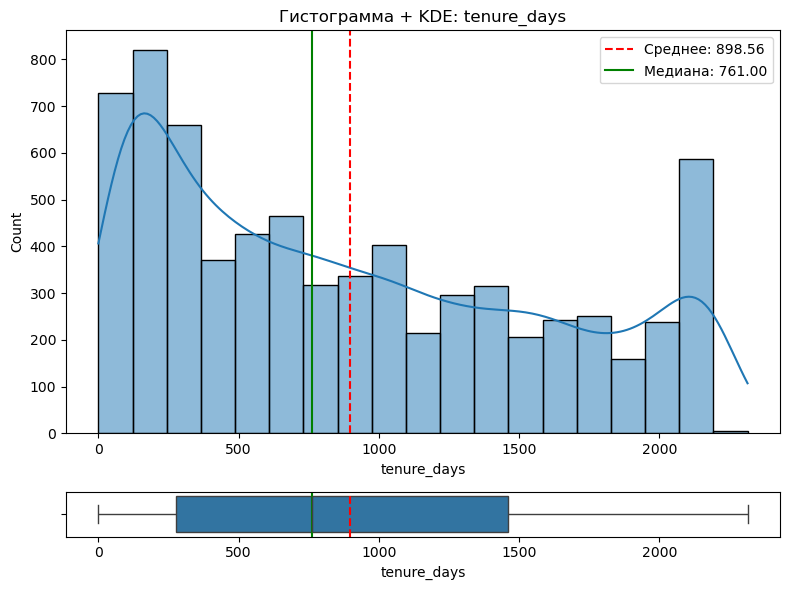

In [32]:
plot_numeric(contract.drop(columns=['customerID', 'is_active']))

#### `personal` — персональные данные клиентов|

In [33]:
plot_numeric(personal.drop(columns='customerID'))

Нет числовых столбцов.


#### `internet` — информация об интернет-услугах

In [34]:
plot_numeric(internet.drop(columns='customerID'))

Нет числовых столбцов.


#### `phone` — информация об услугах телефонии

In [35]:
plot_numeric(phone.drop(columns='customerID'))

Нет числовых столбцов.


## Объединение таблиц

In [36]:
df = contract.copy()

df = df.merge(personal, on='customerID', how='left')

df = df.merge(internet, on='customerID', how='left')

df = df.merge(phone, on='customerID', how='left')

<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> единый датасет собран верно

Заполним отсутствующие услуги.

In [37]:
# internet_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
#                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
# for col in internet_cols:
#     if col in df.columns:
#         df[col] = df[col].fillna('No internet service')

In [38]:
internet_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in internet_cols:
    if col in df.columns:
        df[col] = df[col].fillna('No')

In [39]:
df['MultipleLines'] = df['MultipleLines'].fillna('No phone service')

<div class="alert alert-warning">
    <h2> Комментарий ментора <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b>

У тебя есть бинарные признаки (Yes/No) и в случае добавления к ним еще одного значения (No internet service) получается что бинарные признаки превратятся уже не в бинарные, а в обычные номинальные - с тремя категориями. В чем разница для модели No internet service и No? 

Но один момент -  `multiple_lines` говорит о наличии разного типа подключения к телефонии. При объединении таблиц, в данном столбце появляются пропуски, которые говорят о том, что у клиента НЕТ услуг телефонии вообще. Тут твое заполнение абсолютно верное

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента</b></font>
Исправил в случае с интернет сервисами заполнение пропусков на `No`
</div>

<div class="alert alert-success">
<h2> Комментарий ментора 2<a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> супер, доработано

Посмотрим на итоговый датасет

In [40]:
inspect_table(df)

Размер: (7043, 22)

Первые 5 строк


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,is_active,tenure_days,...,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04,1,31,...,Yes,No,DSL,No,Yes,No,No,No,No,No phone service
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,2071.84,1,1036,...,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17,1,123,...,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1960.60,1,1371,...,No,No,DSL,Yes,No,Yes,Yes,No,No,No phone service
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50,1,153,...,No,No,Fiber optic,No,No,No,No,No,No,No



Информация о типах и пропусках
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           1101 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   is_active         7043 non-null   int64         
 9   tenure_days       7043 non-null   int64         
 10  gender            7043 non-null   object        
 11  SeniorCitizen     7043 non-null   object        
 12  Partner           7043 non-null   object        
 13  Dependents        7043 non-null   object      

None


Количество пропусков по столбцам


customerID             0
BeginDate              0
EndDate             5942
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
is_active              0
tenure_days            0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
MultipleLines          0
dtype: int64


Количество полных дубликатов строк


np.int64(0)

### Создание признаков

In [41]:
add_service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df['num_add_services'] = df[add_service_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)
df['num_add_services'] = df['num_add_services'].astype('category')

### Анализ данных

In [42]:
numeric_cols = [col for col in df.select_dtypes(include=['number']).columns if col != 'is_active']
categorical_cols = [col for col in df.select_dtypes(include=['object', 'category']).columns if col != 'customerID']

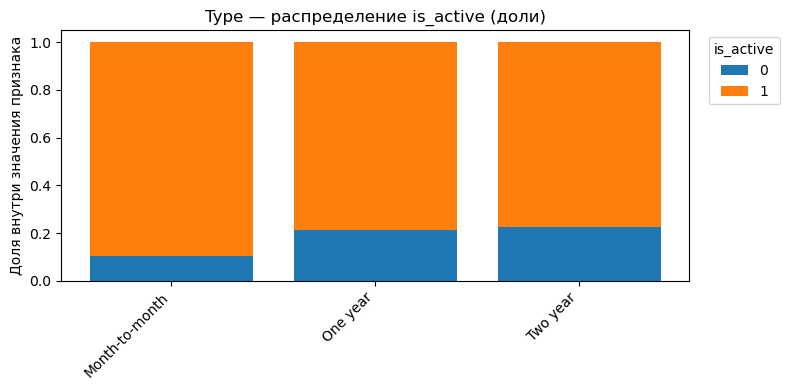

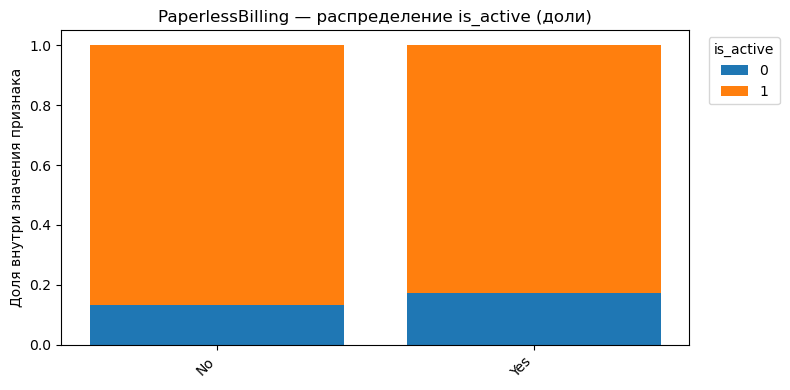

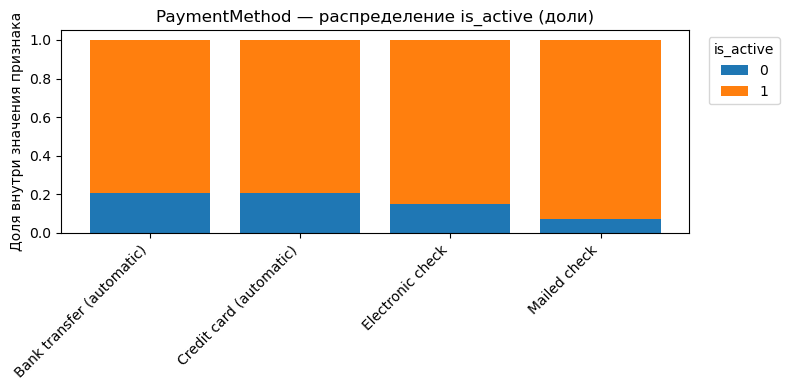

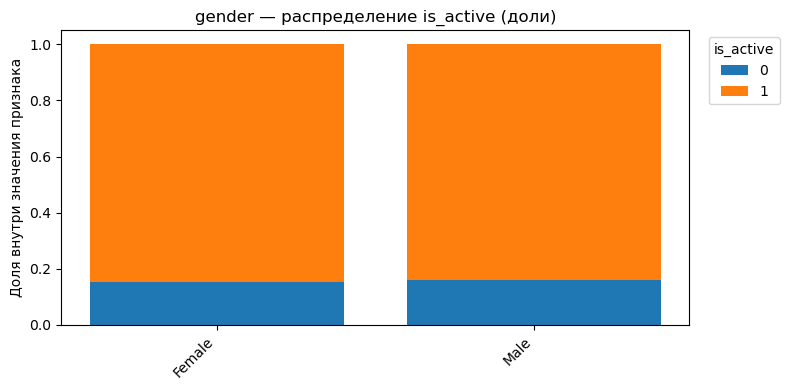

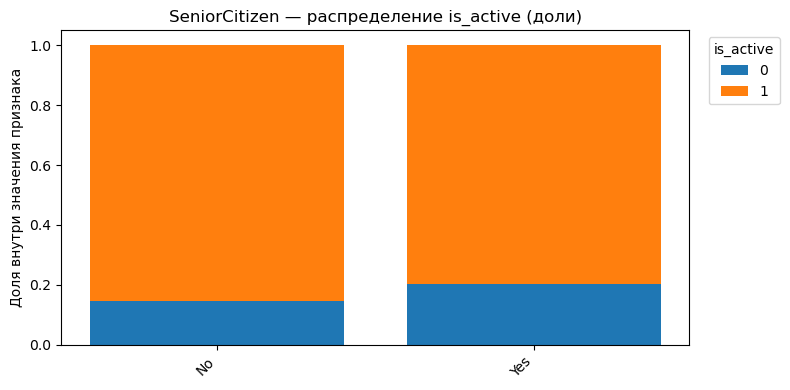

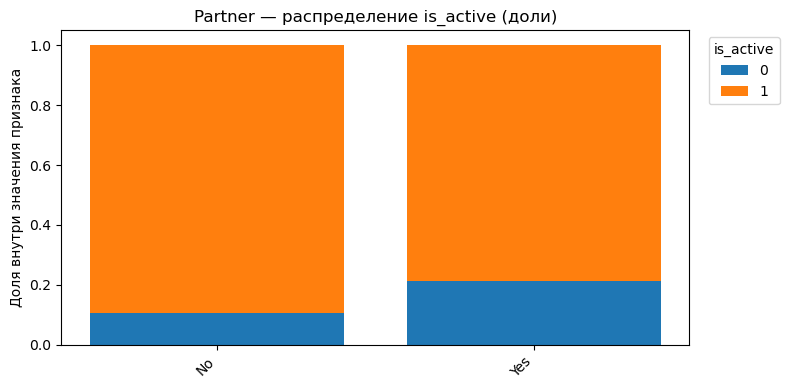

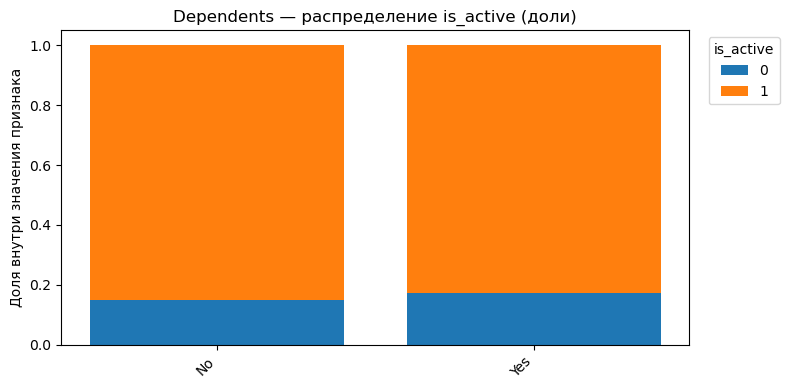

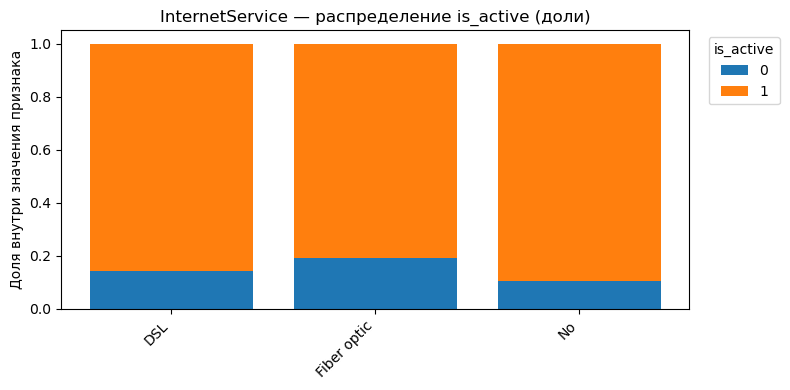

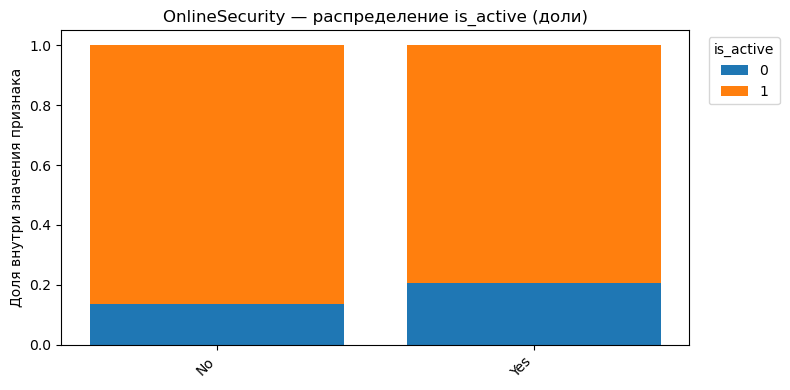

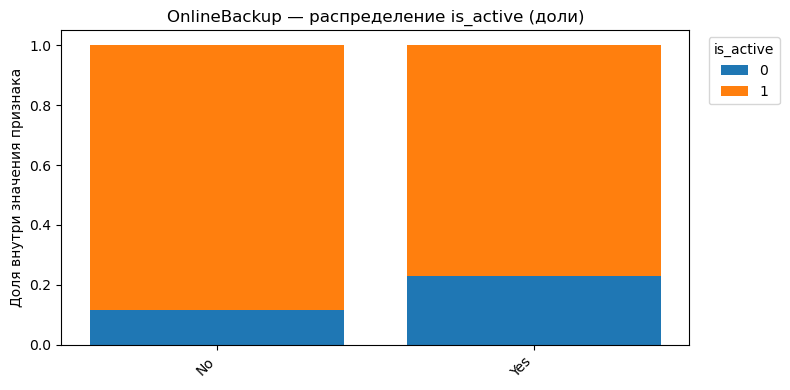

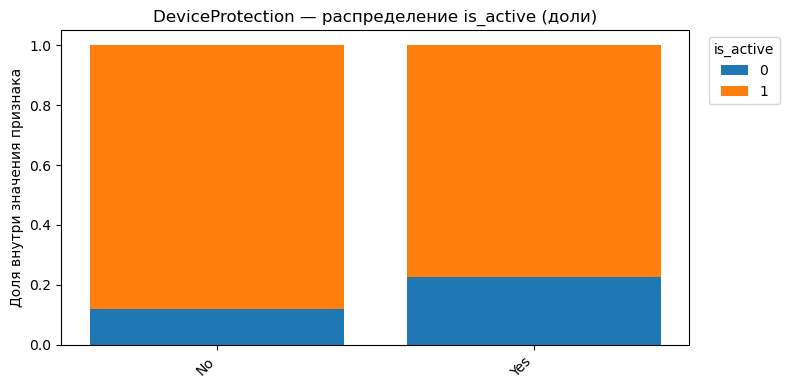

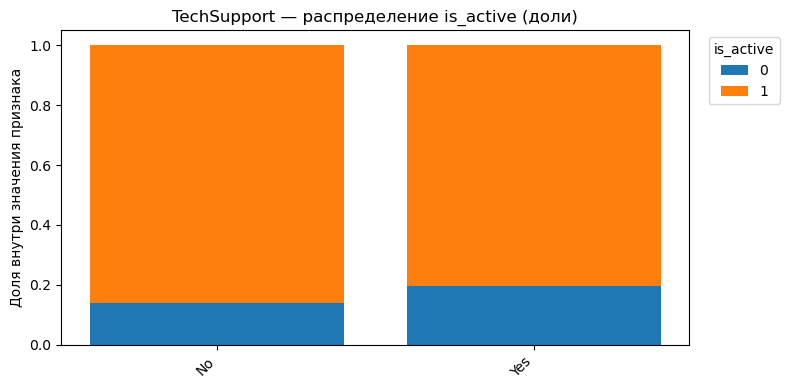

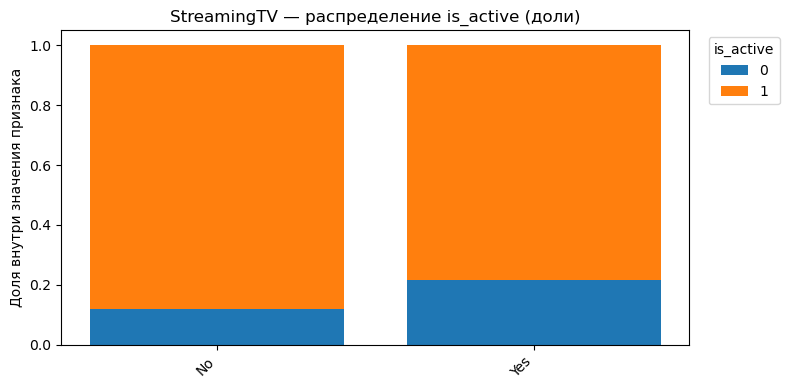

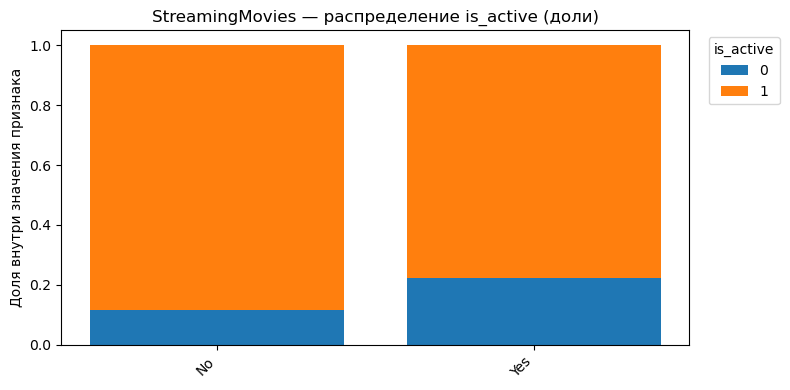

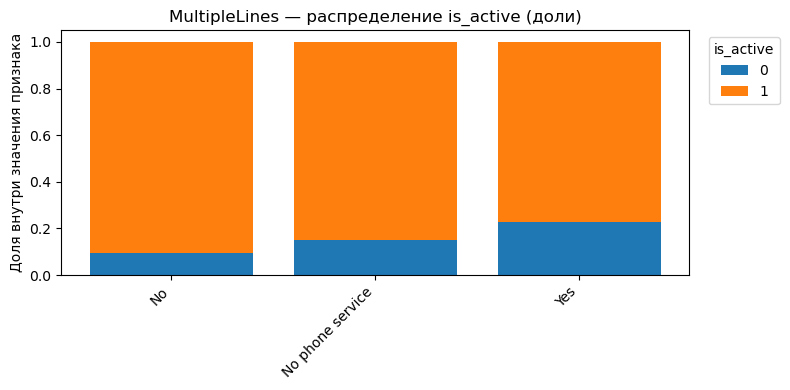

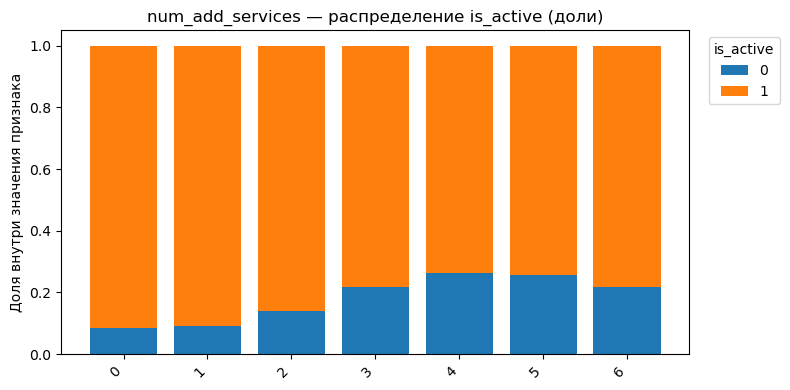

In [43]:
for col in categorical_cols:
    counts = df.groupby([col, "is_active"]).size().unstack(fill_value=0)

    props = counts.div(counts.sum(axis=1), axis=0)
    labels = [str(x) for x in props.index.tolist()]
    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(8, 4))
    bottom = np.zeros(len(labels))
    cols_order = sorted(props.columns, key=lambda v: str(v))
    for c in cols_order:
        vals = props[c].values
        ax.bar(x, vals, bottom=bottom, label=str(c))
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Доля внутри значения признака")
    ax.set_title(f"{col} — распределение is_active (доли)")
    ax.legend(title="is_active", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

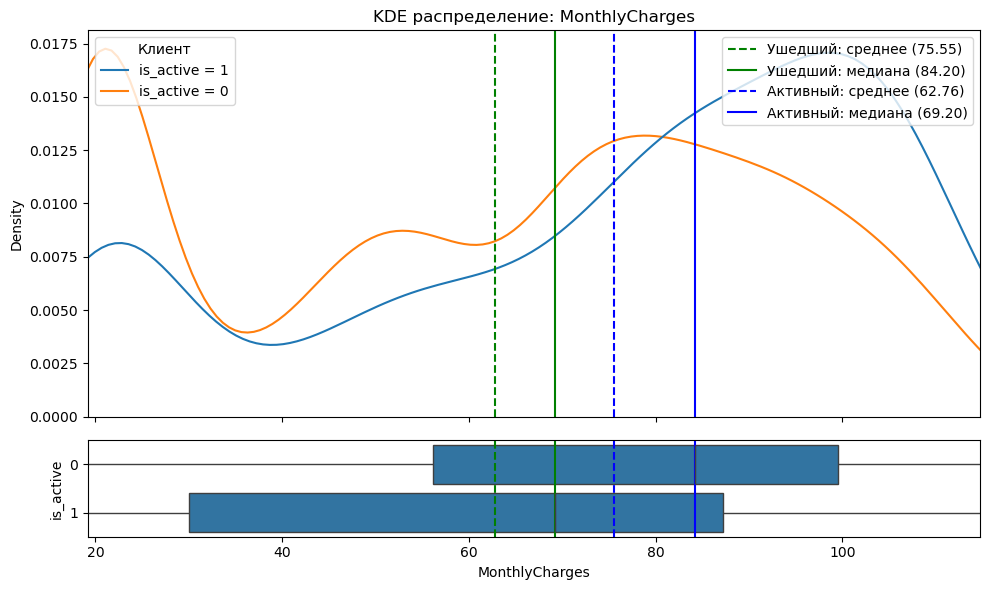

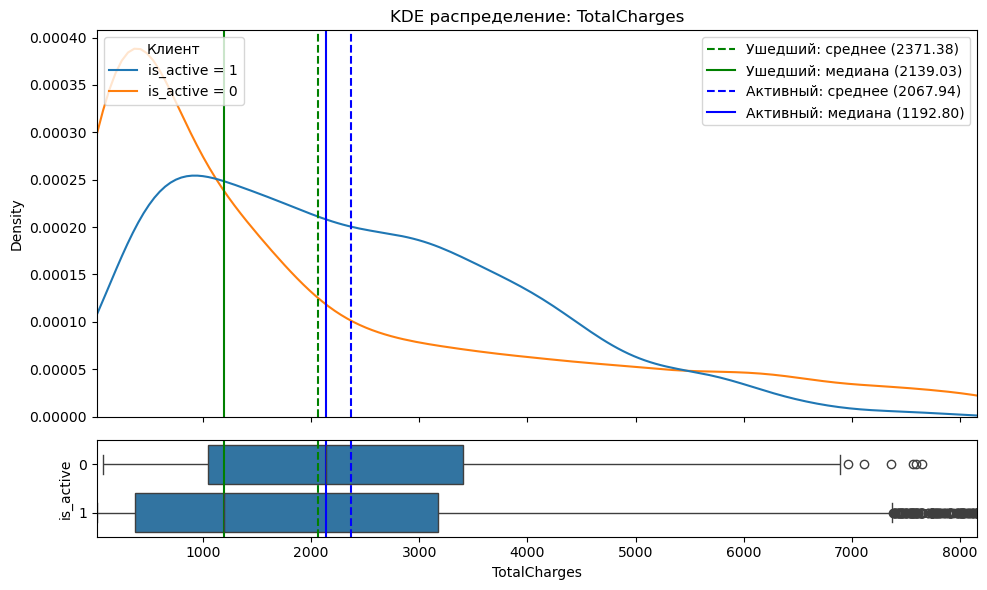

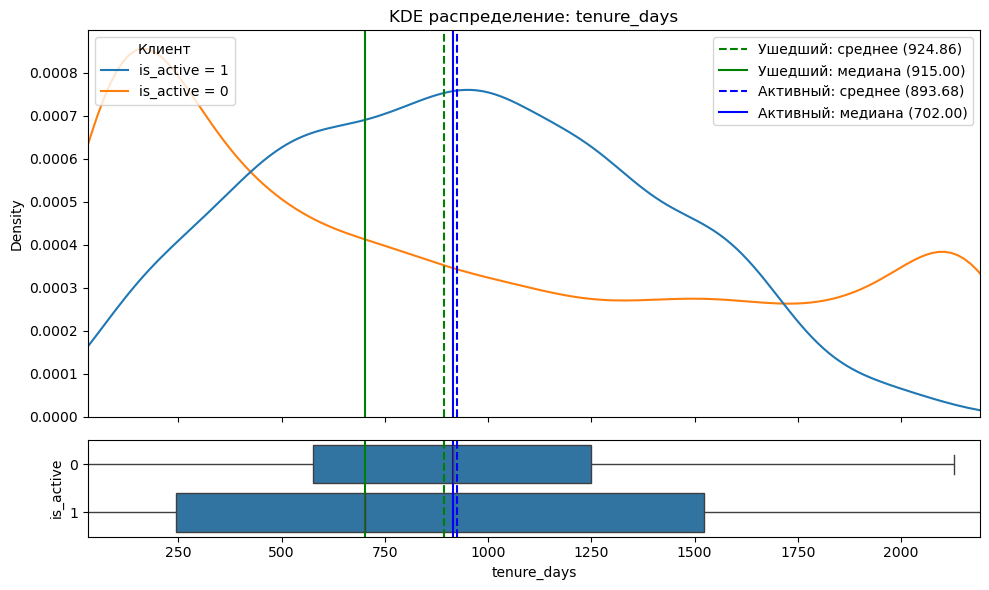

In [44]:
for col in numeric_cols:
        mean_active = df[df["is_active"] == 1][col].mean()
        median_active = df[df["is_active"] == 1][col].median()
        mean_inactive = df[df["is_active"] == 0][col].mean()
        median_inactive = df[df["is_active"] == 0][col].median()
        q_low, q_high = df[col].quantile([0.01, 0.99]).values

        fig, axes = plt.subplots(
            2, 1,
            figsize=(10, 6),
            gridspec_kw={'height_ratios': [4, 1]},
            sharex=True
        )

        sns.kdeplot(
            data=df,
            x=col,
            hue="is_active",
            common_norm=False,
            ax=axes[0],
            legend=False 
        )

        axes[0].plot([], [], color='C0', label='is_active = 1')
        axes[0].plot([], [], color='C1', label='is_active = 0')
        kde_legend = axes[0].legend(title="Клиент", loc="upper left")

        la_mean = axes[0].axvline(mean_active, color='Green', linestyle='--')
        la_med  = axes[0].axvline(median_active, color='Green', linestyle='-')
        li_mean = axes[0].axvline(mean_inactive, color='Blue', linestyle='--')
        li_med  = axes[0].axvline(median_inactive, color='Blue', linestyle='-')

        axes[0].set_title(f"KDE распределение: {col}")
        axes[0].set_xlim(q_low, q_high)

        sns.boxplot(
            data=df,
            x=col,
            y="is_active",
            orient='h',
            ax=axes[1]
        )
        axes[1].axvline(mean_active, color='Green', linestyle='--')
        axes[1].axvline(median_active, color='Green', linestyle='-')
        axes[1].axvline(mean_inactive, color='Blue', linestyle='--')
        axes[1].axvline(median_inactive, color='Blue', linestyle='-')
        axes[1].set_xlabel(col)

        mm_legend = axes[0].legend(
            [la_mean, la_med, li_mean, li_med],
            [
                f"Ушедший: среднее ({mean_inactive:.2f})",
                f"Ушедший: медиана ({median_inactive:.2f})",
                f"Активный: среднее ({mean_active:.2f})",
                f"Активный: медиана ({median_active:.2f})"
            ],
            loc="upper right"
        )

        axes[0].add_artist(kde_legend)

        plt.tight_layout()
        plt.show()   

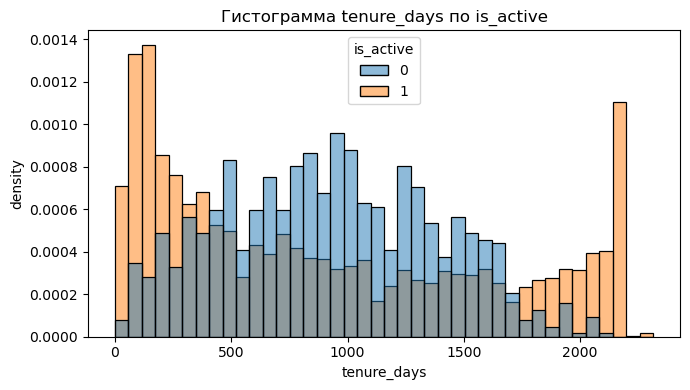

In [45]:
plt.figure(figsize=(7,4))

sns.histplot(
    data=df,
    x="tenure_days",
    hue="is_active",
    stat="density",
    common_norm=False,
    kde=False,
    bins=40,
    alpha=0.5
)

plt.title("Гистограмма tenure_days по is_active")
plt.xlabel("tenure_days")
plt.ylabel("density")

plt.tight_layout()
plt.show()

### Вывод

На всех графиках категориальных признаков видна разница в соотношении активных и ушедших пользователей в зависимости от значения, кроме признака `gender`. На всех числовых признаках также видна разница между активными и ушедшими пользователями.

<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> аналитечаская часть хорошая - понятные графики и выводы, молодец!

### Корреляционный анализ

Подготовим датасет для корреляционного анализа. Выберем все стобцы, что пойдут на дальнейшие этапы.

In [46]:
df_phik = df.drop(columns=['customerID', 'BeginDate', 'EndDate']).copy()

Для phik определим interval_cols

In [47]:
interval_cols = ['MonthlyCharges', 'TotalCharges', 'tenure_days']

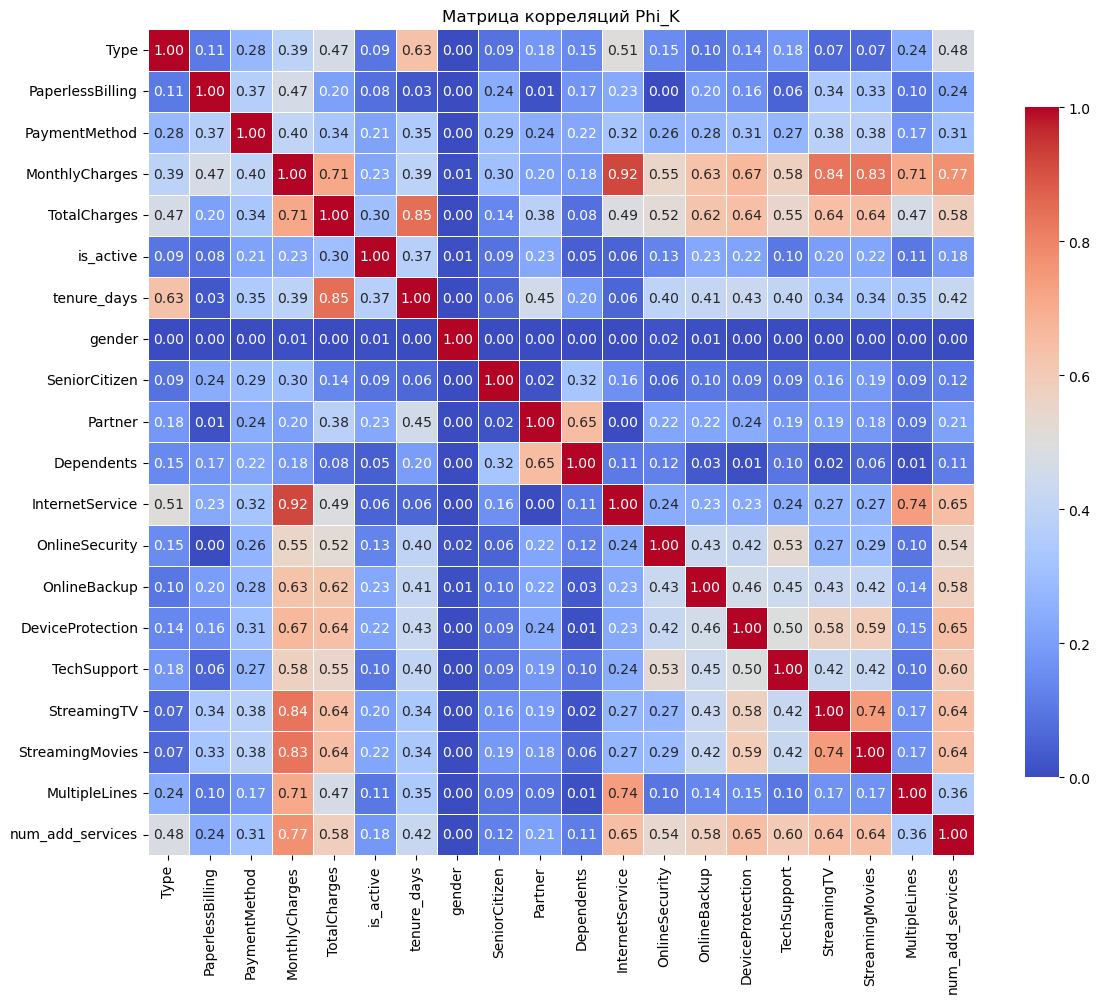

In [48]:
phik_matrix = df_phik.phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(12, 10))
sns.heatmap(
    phik_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True,
    cbar_kws={"shrink": .8},
    linewidths=0.5
)
plt.title('Матрица корреляций Phi_K')
plt.tight_layout()
plt.show()

Мы видим сильную взаимосвязь между признаками обозначающими сервисы, чтобы избежать мультиколлинеарности удалим их, оставив только `InternetService`. Также удалим признак `gender` так как он не демонстрирует какую-либо корреляцию с другими признаками.
Видим также хорошую корреляцию с целевым признаком у признака `tenure_days`.

In [49]:
cols_to_drop = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'gender'
]

In [50]:
df_phik = df_phik.drop(columns=cols_to_drop)

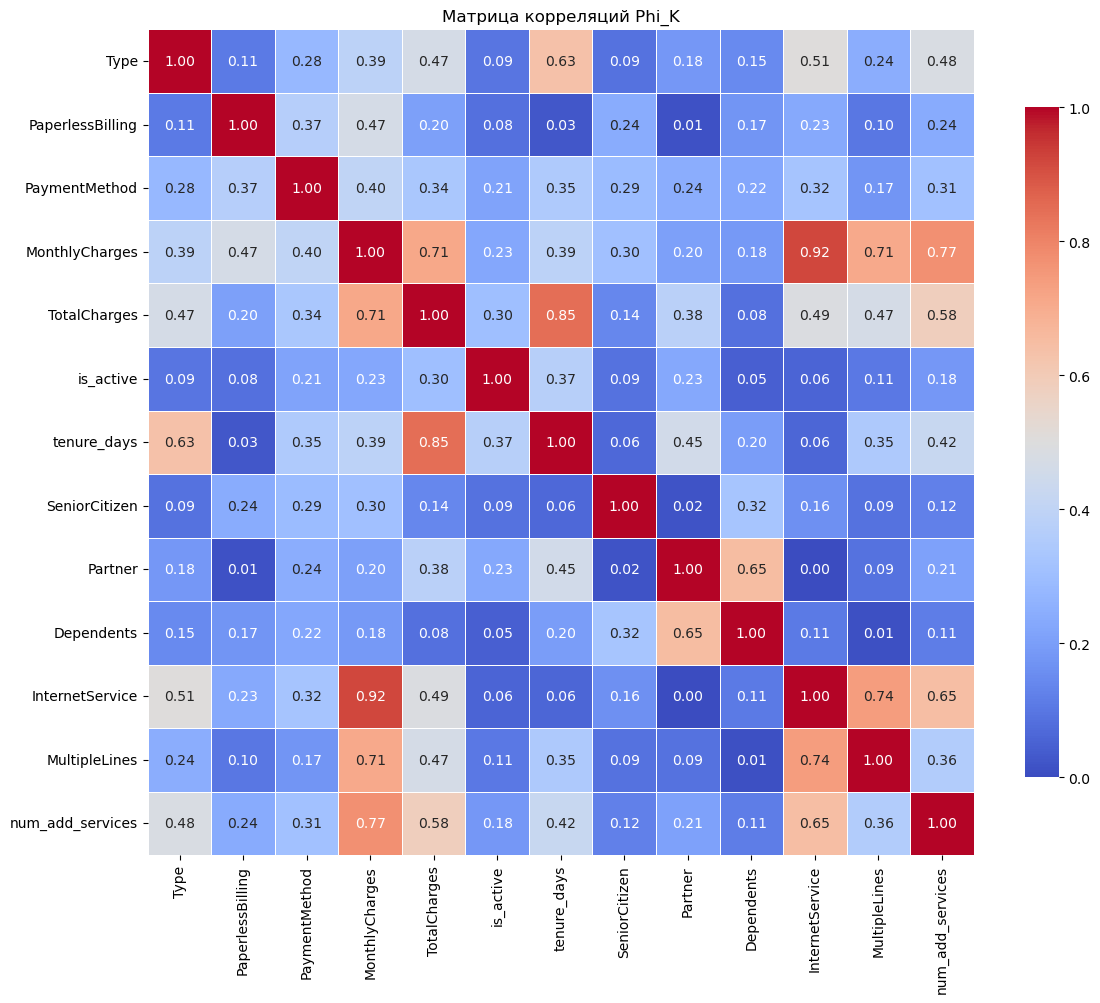

In [51]:
phik_matrix = df_phik.phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(12, 10))
sns.heatmap(
    phik_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True,
    cbar_kws={"shrink": .8},
    linewidths=0.5
)
plt.title('Матрица корреляций Phi_K')
plt.tight_layout()
plt.show()

Получается для обучения моделей мы выбираем следующие столбцы:

- `Type` — тип оплаты: раз в год-два или ежемесячно;
- `PaperlessBilling` — электронный расчётный лист;
- `PaymentMethod` — тип платежа;
- `MonthlyCharges` — расходы за месяц;
- `TotalCharges` — общие расходы абонента;
- `SeniorCitizen` — является ли абонент пенсионером;
- `Partner` — есть ли у абонента супруг или супруга;
- `Dependents` — есть ли у абонента дети;
- `InternetService` — тип подключения;
- `MultipleLines` — подключение телефона к нескольким линиям одновременно;
- `tenure_days` — количество полных месяцев активности;
- `num_add_services` — количество дополнительных сервисов.

In [52]:
df_ml = df[df_phik.columns]

<div class="alert alert-success">
<h2> Комментарий ментора<a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Отлично, все верно, только обрати внимание, что от мультиколинеарности важно избавляться для линейных моделей, для оставльных можно оставить и анализировать уже по значимости признаков после построения моделей.
        
На будущее, полезные ссылки - проверка важности признаков по модели это только один из способов (корреляция в том числе). Используют также аналитические методы проверки гипотез. 

Есть несколько инструментов для отбора признаков, подробнее можно посмотреть в данной статье (Отбор признаков в задачах машинного обучения): https://habr.com/ru/post/550978/

В библиотеке sklearn есть методы mutual_info_regression и mutual_info_classif соответственно для регрессии и классификации.
https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html#sklearn.feature_selection.mutual_info_classif

## Подготовка к обучению

### Модели машинного обучения

Разделим данные на тестовую и тренировочную выборки.

In [53]:
target = 'is_active'

In [54]:
X = df_ml.drop(columns=[target])
y = df_ml[target]

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

Подготовим preprocessor для масштабирования и кодирования данных

In [56]:
num_cols = ['MonthlyCharges', 'TotalCharges', 'tenure_days'] 
cat_cols = [
    'Type', 'PaymentMethod', 'InternetService', 'MultipleLines',
    'PaperlessBilling', 'Partner', 'Dependents', 'SeniorCitizen',
    'num_add_services'
]

In [57]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'
)

<div class="alert alert-warning">
    <h2> Комментарий ментора <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> При обучении моделей на основе деревьев (простые деревья, лес, lgbm, catboost) для высококардинальных категориальных признаков (признаков с большим количеством уникальных значений) нежелательно использовать OHE. Для достижения хорошей точности в этом случае необходимо растить очень глубокое дерево, что достаточно ресурсозатратно. По этой причине такие деревья часто остаются недообученными и несбаланасированными. Вместо OHE для таких признаков лучше использовать порядковое кодирование (<a href = 'https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder'>OrdinalEncoder</a>), благодаря чему при обучении дерева за счет одного шага можно будет делить сразу все категории на два подмножетсва, что поможет не делать слишком много шагов для углубления.
    
    
У lgbm и catboost при этом даже есть специальные параметры, через которые можно указать перечень признаков, требующих кодирования (хотя дефолтно модели сами могут определить, какие из признаков являются категориальными, это не всегда работает надежно, поэтому во избежание недопонимания с моделью лучше вручную прописать нуждающиеся в кодировании признаки): categorical_feature и cat_features соответсвнно.
        
Но обрати нвимание, что для логистическое регрессии допустимо только OneHotEncoder

Определим подбор параметров для моделей.

In [58]:
models_config = {
    'RandomForest': {
        'model': RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight='balanced'
        ),
        'params': {
            'classifier__n_estimators': [50, 100, 200, 300, 500],
            'classifier__max_depth': [5, 10, 15, 20, None],
            'classifier__min_samples_split': [2, 5, 10, 20]
        }
    },

    'XGBoost': {
        'model': XGBClassifier(
            random_state=RANDOM_STATE,
            use_label_encoder=False,
            eval_metric='auc',
            scale_pos_weight=len(y_train) / (2 * sum(y_train))
        ),
        'params': {
            'classifier__n_estimators': [50, 100, 200, 300, 500],
            'classifier__max_depth': [3, 5, 7, 9],
            'classifier__learning_rate': [0.005, 0.01, 0.05, 0.1]
        }
    },

    'LightGBM': {
        'model': LGBMClassifier(
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ),
        'params': {
            'classifier__n_estimators': [50, 100, 200, 300, 500],
            'classifier__max_depth': [-1, 5, 10, 15, 20],
            'classifier__learning_rate': [0.005, 0.01, 0.05, 0.1]
        }
    },

    'LogisticRegression': {
        'model': LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000,
            class_weight='balanced'
        ),
        'params': {
            'classifier__C': [0.01, 0.1, 1, 5, 10, 20],
            'classifier__penalty': ['l1', 'l2']
        }
    },

    'CatBoost': {
        'model': CatBoostClassifier(
            random_state=RANDOM_STATE,
            verbose=0,
            auto_class_weights='Balanced'
        ),
        'params': {
            'classifier__iterations': [50, 100, 200, 400, 600],
            'classifier__depth': [3, 5, 7, 9],
            'classifier__learning_rate': [0.005, 0.01, 0.05, 0.1]
        }
    }
}

### Нейросеть

Подготовим данные для нейросети и настроим подбор параметров.

In [60]:
X_train_nn = preprocessor.fit_transform(X_train).astype(np.float32)
X_test_nn  = preprocessor.transform(X_test).astype(np.float32)

y_train_nn = y_train.values.astype(np.float32)
y_test_nn  = y_test.values.astype(np.float32)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [61]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [62]:
param_grid = [
    {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.3,
     'lr': 0.001, 'batch_size': 64, 'epochs': 50},

    {'hidden_size': 128, 'num_layers': 3, 'dropout': 0.4,
     'lr': 0.0007, 'batch_size': 64, 'epochs': 60},

    {'hidden_size': 256, 'num_layers': 3, 'dropout': 0.3,
     'lr': 0.0005, 'batch_size': 128, 'epochs': 80},

    {'hidden_size': 256, 'num_layers': 4, 'dropout': 0.4,
     'lr': 0.0003, 'batch_size': 128, 'epochs': 100},

    {'hidden_size': 512, 'num_layers': 3, 'dropout': 0.5,
     'lr': 0.0005, 'batch_size': 256, 'epochs': 100},

    {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.2,
     'lr': 0.0015, 'batch_size': 128, 'epochs': 70},

    {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1,
     'lr': 0.001, 'batch_size': 64, 'epochs': 60}
]

In [63]:
def make_model(input_dim, hidden, layers, drop):
    m = nn.Sequential()
    d = input_dim
    for i in range(layers):
        m.add_module(f"lin_{i}", nn.Linear(d, hidden))
        m.add_module(f"relu_{i}", nn.ReLU())
        m.add_module(f"drop_{i}", nn.Dropout(drop))
        d = hidden
    m.add_module("out", nn.Linear(d, 1))
    return m

## Обучение моделей

Переходим к обучению моделей.

In [64]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [65]:
results = []

for name, config in models_config.items():
    print(f"\n=== {name} ===")

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', config['model'])
    ])
    
    search = RandomizedSearchCV(
        pipe,
        config['params'],
        n_iter=35,
        cv=cv,
        scoring='roc_auc',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )
    
    search.fit(X_train, y_train)

    best_est = search.best_estimator_
    cv_score = search.best_score_
    
    results.append({
        'Model': name,
        'CV_ROC_AUC': cv_score,
        'Estimator': best_est
    })
    
    print(f"CV ROC-AUC = {cv_score:.4f}")


=== RandomForest ===
Fitting 5 folds for each of 35 candidates, totalling 175 fits
CV ROC-AUC = 0.8248

=== XGBoost ===
Fitting 5 folds for each of 35 candidates, totalling 175 fits
CV ROC-AUC = 0.8966

=== LightGBM ===
Fitting 5 folds for each of 35 candidates, totalling 175 fits
[LightGBM] [Info] Number of positive: 4456, number of negative: 826
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 731
[LightGBM] [Info] Number of data points in the train set: 5282, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

In [67]:
best_score = -np.inf
best_model = None
best_params = None

In [68]:
for params in param_grid:
    fold_scores = []

    for tr_idx, val_idx in cv.split(X_train_nn, y_train_nn):
        X_tr, X_val = X_train_nn[tr_idx], X_train_nn[val_idx]
        y_tr, y_val = y_train_nn[tr_idx], y_train_nn[val_idx]

        model = make_model(
            X_tr.shape[1],
            params['hidden_size'],
            params['num_layers'],
            params['dropout']
        ).to(device)

        pos_weight = len(y_tr) / (2 * np.sum(y_tr))
        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight], dtype=torch.float32).to(device)
        )
        optimizer = torch.optim.AdamW(model.parameters(), lr=params['lr'])

        train_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(
                torch.tensor(X_tr).to(device),
                torch.tensor(y_tr).view(-1, 1).to(device)
            ),
            batch_size=params['batch_size'],
            shuffle=True
        )

        for epoch in range(params['epochs']):
            model.train()
            epoch_loss = 0
            for xb, yb in train_loader:
                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

        model.eval()
        with torch.no_grad():
            logits = model(torch.tensor(X_val).to(device)).cpu().numpy()
            probas = 1 / (1 + np.exp(-logits))
            fold_scores.append(roc_auc_score(y_val, probas))

    mean_score = np.mean(fold_scores)

    print(f"Параметры: {params} | CV ROC-AUC = {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_params = params
        best_model = make_model(
            X_train_nn.shape[1],
            params['hidden_size'],
            params['num_layers'],
            params['dropout']
        ).to(device)

        pos_weight = len(y_train_nn) / (2 * np.sum(y_train_nn))
        criterion_full = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight], dtype=torch.float32).to(device)
        )
        optimizer_full = torch.optim.AdamW(best_model.parameters(), lr=params['lr'])

        full_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(
                torch.tensor(X_train_nn).to(device),
                torch.tensor(y_train_nn).view(-1, 1).to(device)
            ),
            batch_size=params['batch_size'], shuffle=True
        )

        for epoch in range(params['epochs']):
            best_model.train()
            for xb, yb in full_loader:
                optimizer_full.zero_grad()
                logits = best_model(xb)
                loss = criterion_full(logits, yb)
                loss.backward()
                optimizer_full.step()

print(f"\nЛучшая конфигурация PyTorchNN: {best_params}")
print(f"CV ROC-AUC лучшей модели: {best_score:.4f}")

Параметры: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 64, 'epochs': 50} | CV ROC-AUC = 0.8166
Параметры: {'hidden_size': 128, 'num_layers': 3, 'dropout': 0.4, 'lr': 0.0007, 'batch_size': 64, 'epochs': 60} | CV ROC-AUC = 0.8214
Параметры: {'hidden_size': 256, 'num_layers': 3, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 128, 'epochs': 80} | CV ROC-AUC = 0.7968
Параметры: {'hidden_size': 256, 'num_layers': 4, 'dropout': 0.4, 'lr': 0.0003, 'batch_size': 128, 'epochs': 100} | CV ROC-AUC = 0.8127
Параметры: {'hidden_size': 512, 'num_layers': 3, 'dropout': 0.5, 'lr': 0.0005, 'batch_size': 256, 'epochs': 100} | CV ROC-AUC = 0.7960
Параметры: {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.0015, 'batch_size': 128, 'epochs': 70} | CV ROC-AUC = 0.7818
Параметры: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 64, 'epochs': 60} | CV ROC-AUC = 0.8194

Лучшая конфигурация PyTorchNN: {'hidden_size': 128, 'num_layers':

In [69]:
results.append({
    'Model': 'PyTorchNN',
    'CV_ROC_AUC': best_score,
    'Estimator': best_model
})

Метрики получились удачные, при этом 

## Выбор модели

Выбираем лучшую модель

In [70]:
results_df = pd.DataFrame(results)

In [71]:
results_df = results_df.sort_values('CV_ROC_AUC', ascending=False).reset_index(drop=True)
display(results_df[['Model', 'CV_ROC_AUC']])

,Model,CV_ROC_AUC
0,CatBoost,0.899253
1,XGBoost,0.896571
2,LightGBM,0.873412
3,RandomForest,0.824841
4,PyTorchNN,0.821374
5,LogisticRegression,0.762609


In [72]:
best_model_name = results_df.iloc[0]['Model']
best_estimator = results_df.iloc[0]['Estimator']

In [73]:
print(f"\nЛучшая модель по CV: {best_model_name}")


Лучшая модель по CV: CatBoost


## Финальное предсказание

In [74]:
if best_model_name == "PyTorchNN":
    X_test_final = preprocessor.transform(X_test).astype(np.float32)

    best_estimator.eval()
    with torch.no_grad():
        logits = best_estimator(torch.tensor(X_test_final).to(device)).cpu().numpy()
        y_pred_proba = 1 / (1 + np.exp(-logits)).flatten()

else:
    y_pred_proba = best_estimator.predict_proba(X_test)[:, 1]

final_roc = roc_auc_score(y_test, y_pred_proba)
final_acc = accuracy_score(y_test, (y_pred_proba > 0.5).astype(int))

print(f"ROC-AUC (тест): {final_roc:.4f}")
print(f"Accuracy (тест): {final_acc:.4f}")

ROC-AUC (тест): 0.9220
Accuracy (тест): 0.8779


Метрики на тесте также высокие, гипотезу о переобучении можно отвергнуть.

<div class="alert alert-success">
<h2> Комментарий ментора 2<a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> теперь хорошо

Построим матрицу ошибок для лучшей модели

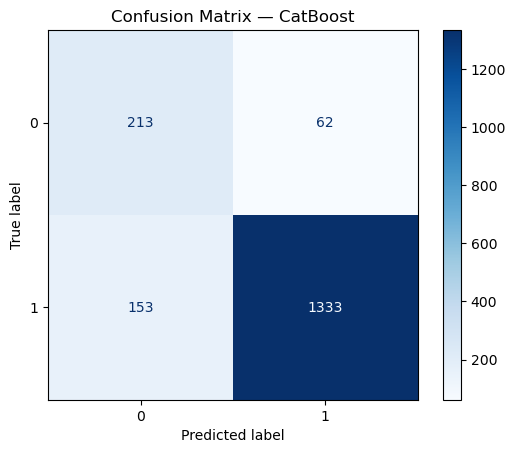

In [75]:
cm = confusion_matrix(y_test,(y_pred_proba > 0.5).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

Мы видим, очень хорошее соотношение. Мы вряд-ли можем что-то улучшить здесь, попытки уменьшить количество False Positive скорее всего сильно увеличат количество False Negative, так как предложение различных дополнительных услуг не бесплатно для компании, мы не можем себе такое позволить.

In [76]:
preproc = best_estimator.named_steps["preprocessor"]
cat_model = best_estimator.named_steps["classifier"]

In [77]:
feature_names = preproc.get_feature_names_out()

In [78]:
importances = getattr(cat_model, "feature_importances_", None)

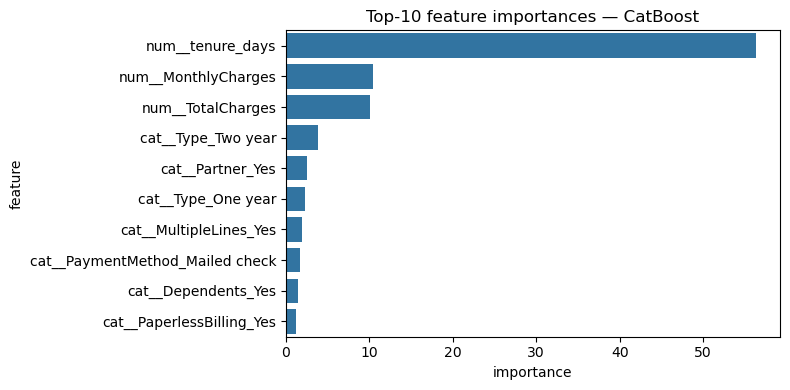

In [79]:
fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

top_features = fi.head(10)

plt.figure(figsize=(8, max(4, 0.4 * 10)))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title(f"Top-{10} feature importances — CatBoost")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

Наиболее значимыми стали признаки `tenure_days`, `TotalCharges` и `MonthlyCharges`, остальные признаки по значимости заметно уступают этим.

<div class="alert alert-success">
<h2> Комментарий ментора <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> плюс за раздел, понятно как модель принимает решение. В будущем можно оставить наиболее значимые признаки и посмотреть на качество модели.

## Выводы

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента</b></font>
Я подозреваю, что есть утечка данных, но не могу ее обнаружить. Логически не вижу, как именно `tenure_days` или `TotalCharges` выдают целевой признак. Если модель будет повторно строиться на новых данных, то будет проведен такой же срез, как было сделано с `tenure_days`, поэтому я не знаю, как этот признак приводит к утечке данных.
</div>

<div class="alert alert-warning">
    <h2> Комментарий ментора <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> здесь косвенная утечка из-за сочетания признаков tenure_days и TotalCharges. Тк по сути tenure_days восстанавливает дату начала контракта при твоем определении от среза данных, а TotalCharges - эо по сути длительность контракта, одно плюс другое = дата окончания контракта и если она меньше среза, то получаем таргет.
        
Нужно исправить вычисление tenure_days или попробовать совсем без него (он явно будет сильно коррелировать с TotalCharges)

В ходе проекта была разработана высокоэффективная модель предсказания оттока клиентов. Наилучший результат показал алгоритм CatBoost с ROC-AUC 0.8993 на кросс-валидации и 0.922 на тестовой выборке, что значительно превосходит минимальный порог в 0.85.

Модель выявила три ключевых фактора, наиболее сильно влияющих на отток: Длительность контракта (tenure_days) — самый значимый признак, что соответствует бизнес-логике: новые клиенты имеют повышенный риск оттока, тогда как лояльные абоненты редко покидают оператора

Матрица ошибок показывает оптимальное соотношение типов ошибок:
- Низкое количество ложных положительных (False Positive) предсказаний — оператор не будет тратить ресурсы на удержание стабильных клиентов
- Минимальное число ложных отрицательных (False Negative) — почти все склонные к оттоку клиенты будут своевременно выявлены

Стоит отметить, что при попытке снижения числа ложных срабатываний (False Positive) неизбежно возрастало бы количество пропущенных уходящих клиентов (False Negative). Учитывая высокую стоимость удержания клиента по сравнению с потерей дохода от его ухода, текущий баланс ошибок представляет оптимальное бизнес-решение.

Бизнес-рекомендации:
- Для улучшения качества предсказаний можно дополнительно собирать данные, например, об обращениях к тех. поддержке, проводить опросы о том, что пользователи, хотят видеть в продукте.
- Провести A/B тестирование различных стратегий удержания. Какие сервисы позваляют с минимальными издержками повысить длительность контракта у пользователя.
- Доработать модель с учетом экономической целесообразности каждого действия. Можно дополнительно исследовать значимость наиболее дешевых для оператора "Теледом" сервисов для удержания клиента.
- Создать систему обратной связи для постоянного переобучения модели на новых данных.

<div style="border:solid Chocolate 2px; padding: 40px">

<h2>✔️ Заключение ментора: <a class="tocSkip"> </h2> 
    
<b>Валерий</b>, работа почти готова, но нужно еще немного дорабоать, мои комментарии ты увидишь выше.

Жду твою работу! :)

<div style="border:solid Chocolate 2px; padding: 40px">

<h2>✔️ Финальное заключение ментора: <a class="tocSkip"> </h2> 
    
<b>Валерий</b>, замечания доработаны! Работа получилась большой и полной, молодец! 
    
Поздравляю с получением диплома о новой специальности!!!!<br> 
    
Немного фидбека о твоей работе:
- наличие выводов и комментариев;
- хорошая интерпретация по моделям;
- использование нескольких моделей обучения - супер;
- хорошая аналитическая часть.
    
Сейчас ты можешь доработать этот проект с учетом рекомендаций, удалить наши с тобой комментарии и добавить себе в портфолио — лучше это сделать в ближайшее время, пока все нюансы еще отложились в памяти.

Далее, хочу добавить некоторые ссылки на полезные ресурсы по машинному обучению:

https://academy.yandex.ru/handbook/ml/ онлайн-учебник от Школы анализа данных Яндекса, в котором описаны теоретические основы работы моделей машинного обучения;

В некоторых компаниях при устройстве на работу или стажировку, например в Яндексе, нужно решить тест на алгоритмические задачи. По алгоритмам есть много разных курсов, платных и бесплатных. Можно попробовать Тренировки по Алгоритмам от Яндекса https://yandex.ru/yaintern/algorithm-training (бесплатно, хороший курс). Насколько знаю, у Практикума тоже есть курс по алгоритмам.
    
    
Также дам пару рекомендаций в целом о дальнейшей карьере:
    
- табличные данные и классический ML - это интересно, но постепенно отходит на второй план по мере роста популярности нейронных сетей и глубокого обучения. Поэтому рекомендую активно в них погружаться, выбрать близкую душе специализацию (CV или NLP) и осваивать её;
    
- Python - must have: важно не только хорошо уметь работать с алгоримами машинного обучения, но и деплоить решения, настраивать пайплайны и миграции, писать качественный, чистый и отказоустойчивый код, чтобы быть хорошим ML инженером - это тоже очень важный аспект деятельности дата сайентиста, поэтому тут тоже очень больше поле для деятельности;
    
- облачные технологии: сейчас всё меньше заказчиков работают на собственных мощностях, отдавая предпочтения облачной инфраструктуре: она проще в обслуживании и масштабировании и позволяет экономить на железе. Сейчас многие технологические гиганты типа Amazon, Microsoft и др. имеют собственные облачные решения, которые они продают как продукты - хорошее понимание облачных технологий будет твоим сильным конкурентным преимуществом. На сайтах этих компаний много обучающих курсов, рекомендую уделить этому внимание.
    
***

    
Проект принимаю и удачи в дальнейшем пути!
    
    
</font>